# Исследовательский анализ данных заведений общественного питания Москвы


### Цели и задачи проекта

Проведение исследовательского анализа рынка заведений общественного питания Москвы с целью выбора заведения для инвестиций.

### Описание данных

Для анализа даны два датасета, содержащих информацию о заведениях общественного питания и информацию о среднем чеке в заведениях общественного питания.

В датасет, содержащий информацию о заведениях общественного питания входят столбцы с
  - названием заведения
  - адресом заведения
  - административным районом
  - категории заведения
  - информации о режиме работы
  - рейтингом заведения
  - информация, является ли заведение сетевым
  - количеством посадочных мест
  
В датасет, содержащий информацию о среднем чеке в заведениях общественного питания входят столбцы с
  - категорией цен
  - средней стоимостью заказа
  - среднего чека
  - числа с оценкой одной чашки капучино

### Содержимое проекта

 - Загрузка данных и знакомство с ними
 - Промежуточный вывод
 - Подготовка единого датафрейма
 - Предобработка данных
 - Промежуточный вывод
 - Исследовательский анализ данных
 - Промежуточный вывод
 - Итоговый вывод и рекомендации

## 1. Загрузка данных и знакомство с ними


In [64]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
!pip install phik

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 10.6 MB/s eta 0:00:00


In [4]:
# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

In [5]:
# Выгружаем данные в переменные rest_info и rest_price
info_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
price_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

#### Начинаем знакомство с данными, выведем информацию первых 5 строк из датафрейма info_df

 - Получим информацию о количестве ненулевых значений, типах данных столбцов и объёме памяти, которую занимает объект

In [6]:
# Выведем первые 5 строк датафрейма info_df
info_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [7]:
# Выводим информацию о датафрейме
info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


 - Узнаем количество строк и столбцов в датафрейме

In [8]:
# Подсчет количества строк в датафрейме
info_df.shape

(8406, 9)

 - Выявим проблемы в данных, посмотрим аномально большие значения, аномально маленькие для учета в дальнейшей обработке данных

In [9]:
# Выведем статистику для числовых столбцов
info_df.describe()

,rating,chain,seats
count,8406.000000,8406.000000,4795.000000
mean,4.229895,0.381275,108.421689
std,0.470348,0.485729,122.833396
min,1.000000,0.000000,0.000000
25%,4.100000,0.000000,40.000000
50%,4.300000,0.000000,75.000000
75%,4.400000,1.000000,140.000000
max,5.000000,1.000000,1288.000000


 - Посмотрим количество повторов

In [10]:
# Вывод количества дубликатов
info_df.duplicated().sum()

np.int64(0)

   Используя данные методы анализа можно сказать, что всего в датафрейме 8406 строк, диапазон индексов — от 0 до 8405 и 9 столбцов. В данных 2 столбца типа float64, 1 столбец типа int64 и 6 столбцов типа object. Датафрейм занимает 591,2 Кбайта памяти. В данных отсутствуют дубликаты.

###### Выведем информацию первых 5 строк из датафрейма price_df

 - Получим информацию о количестве ненулевых значений, типах данных столбцов и объёме памяти, которую занимает объект

In [11]:
# Выведем первые 5 строк датафрейма price_df
price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [12]:
# Выводим информацию о датафрейме
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


 - Узнаем количество строк и столбцов в датафрейме

In [13]:
# Подсчет количества строк в датафрейме
price_df.shape

(4058, 5)

 - Выявим проблемы в данных, посмотрим аномально большие значения, аномально маленькие для учета в дальнейшей обработке данных

In [14]:
# Выведем статистику для числовых столбцов
price_df.describe()

,middle_avg_bill,middle_coffee_cup
count,3149.000000,535.000000
mean,958.053668,174.721495
std,1009.732845,88.951103
min,0.000000,60.000000
25%,375.000000,124.500000
50%,750.000000,169.000000
75%,1250.000000,225.000000
max,35000.000000,1568.000000


 - Посмотрим количество повторов

In [15]:
# Вывод количества дубликатов
price_df.duplicated().sum()

np.int64(0)

Во стором датафрейме 4058 строк, диапазон индексов — от 0 до 4057 и 5 столбцов. Данные содержат 2 столбца типа float64 и 3 столбца типа object. Датафрейм занимает 158,6 Кбайта памяти. В данных также отсутствуют дубликаты.

---

### Промежуточный вывод


На первый взгляд, названия столбцов отражают содержимое данных и прописаны в удобном для работы виде. В датасете info_df я бы привела поле seats к формату int64, nullable типа для обработки отсутствующих данных после проверки на null. Также в данных в поле seats присутствуют аномально большие значения по количеству посадочных мест.

В датасете price_df присутствуют аномальные значения в полях middle_avg_bill и middle_coffee_cup это видно из сравнения максимальной стоимоси или счета с 3 квартилем. Хотя можно предположить. что заказ на сумму 35000 был сделан к какому-то праздничному событию, что в полне реально, но эти данные будут искажать полный анализ.

### Подготовка единого датафрейма


In [16]:
# Объединение датафреймов
df = info_df.merge(price_df, how='left', on='id')

In [17]:
# Проверка объединения
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


In [18]:
len(df)

8406

## 2. Предобработка данных


In [19]:
# Основная статистика
df['seats'].describe()

,seats
count,4795.000000
mean,108.421689
std,122.833396
min,0.000000
25%,40.000000
50%,75.000000
75%,140.000000
max,1288.000000


In [20]:
# Проверка на отрицательные значения (Не обязательно, так как min = 0)
df[df['seats'] > -1]['seats'].describe()

,seats
count,4795.000000
mean,108.421689
std,122.833396
min,0.000000
25%,40.000000
50%,75.000000
75%,140.000000
max,1288.000000


Приведем столбец seats к nullable типу, который поддерживает пропуски внутри себя.

In [21]:
# Вывод измененного типа данных
df['seats'] = df['seats'].astype('Int64')
display(df.dtypes)

,0
id,object
name,object
category,object
address,object
district,object
hours,object
rating,float64
chain,int64
seats,Int64
price,object


In [22]:
# Вывод количества пропусков в каждом столбце
missing_values = df.isna().sum().sort_values(ascending=False)
display(missing_values)

,0
middle_coffee_cup,7871
middle_avg_bill,5257
price,5091
avg_bill,4590
seats,3611
hours,536
district,0
category,0
name,0
id,0


In [23]:
# Вывод количества пропусков в каждом столбце
missing_data = (df.isna().sum() / len(df) * 100).round(2)
missing_data_sorted = missing_data.sort_values(ascending=False)
display(missing_data_sorted)


,0
middle_coffee_cup,93.64
middle_avg_bill,62.54
price,60.56
avg_bill,54.60
seats,42.96
hours,6.38
district,0.00
category,0.00
name,0.00
id,0.00


In [24]:
# Отсортируем по категориям
sort_category = df.sort_values(by ='category')
display(sort_category)

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
5957,57329c9799944e8e8ffd7f22f94e567d,Riverside,"бар,паб","Москва, Фрунзенская набережная, 32",Центральный административный округ,"ежедневно, 09:00–00:00",4.4,0,30,NaN,NaN,NaN,NaN
1063,29dedd500d1545c3b6076d0fe33a7755,Барслона,"бар,паб","Москва, проспект Мира, 211к2",Северо-Восточный административный округ,"ежедневно, 10:00–22:00",4.1,0,<NA>,NaN,NaN,NaN,NaN
4221,42006a621f2846e7b4b4491227593dff,Remedy Junk food Family,"бар,паб","Москва, Пресненская набережная, 12",Центральный административный округ,"пн-пт 10:00–22:00; сб,вс 13:00–21:00",4.6,0,300,средние,Средний счёт:800–1200 ₽,1000.0,NaN
4229,8819e9678b9940c5b0eaa146f7da52d2,Мармарис,"бар,паб","Москва, улица Арбат, 22/2с1",Центральный административный округ,"ежедневно, 10:00–03:00",3.7,0,<NA>,NaN,NaN,NaN,NaN
4241,abe7430f093e4716b261648de4adb4f4,Городское кафе и бар,"бар,паб","Москва, Новодевичий проезд, 4",Центральный административный округ,"ежедневно, 10:00–23:00",4.4,0,90,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8094,ab075a94b55a4bb4b4b302ffb8dabc46,Елисей,столовая,"Москва, Дубининская улица, 90",Южный административный округ,пн-пт 08:00–18:00,4.4,0,50,средние,Средний счёт:200–300 ₽,250.0,NaN
1878,6771545644a340a099b06dc47df97b0e,Столовая-кафе Росинка,столовая,"Москва, Новослободская улица, 45А",Центральный административный округ,пн-пт 08:00–19:00,4.5,1,<NA>,средние,Средний счёт:280–290 ₽,285.0,NaN
7159,adc792b29bdf49a081cf5ac01dfed0b5,Food Story,столовая,"Москва, улица Садовники, 11А",Южный административный округ,пн-пт 11:00–18:00,4.3,0,<NA>,NaN,NaN,NaN,NaN
2773,a7b39b89e98147c782fb4629dac72bac,Смакбери,столовая,"Москва, Тюменский проезд, 5, стр. 1",Восточный административный округ,пн-чт 08:00–18:00; пт 08:00–17:00; сб 10:00–17:00,4.1,0,<NA>,NaN,Средний счёт:250 ₽,250.0,NaN


Датафрейм содержит много пропусков. Основные пропуски в столбцах со стоимостью товара. Пропуски в столбце hours (режим работы) я бы не трогала, так как они составляют менее 10% от общего количества.

 Пропуски seats могут быть просто не указаны, либо в заведении просто нет сидячих мест, типа стрит фуда, также заведение может быть типа даркстора, где работают только на вынос. Для более детального анализа пропусков по seats я бы сгруппировала их по категории заведения и посмотрела бы действительно ли мои предположения верны.

In [25]:
# Группируем по категории и количеству пропусков, сортируем по убыванию
mis_seats = df.groupby('category')['seats'].apply(lambda x: x.isna().sum())
mis_seats_sorted = mis_seats.sort_values(ascending=False)
display(mis_seats_sorted)

,seats
category,
кафе,1160
ресторан,773
кофейня,662
"бар,паб",297
быстрое питание,254
пиццерия,206
столовая,151
булочная,108


После группировки видно, что для многих категорий по идее должны присутствовать посадочные места, на мой взгляд, мы не сможем корректно заменить пропуски. Поэтому я бы оставила пропуски без изменений.

Для столбцов price и avg_bill я бы заменила пропуски на "нет данных", так как данные поля относятся к категориальным значениям, по ним можно будет осуществлять группировку.

In [26]:
# Замена пропусков в столбцах price и avg_bill
df['price'] = df['price'].fillna('нет данных')
df['avg_bill'] = df['avg_bill'].fillna('нет данных')

Можно посмотреть сколько пропусков для каждой ка тегории заведения и посмотреть медиану среднего чека по категориям c учетом района.


In [27]:
# Группируем по категории и количеству пропусков
mis_middle_avg_bill = df.groupby('category')['middle_avg_bill'].apply(lambda x: x.isna().sum()).sort_values(ascending=False)
display(mis_middle_avg_bill)

,middle_avg_bill
category,
кафе,1684
кофейня,1213
ресторан,1003
"бар,паб",416
быстрое питание,366
пиццерия,238
булочная,203
столовая,134


In [28]:
# Группируем по категории и медиане среднего чека
med_middle_avg_bill = df.groupby('category')['middle_avg_bill'].apply(lambda x: x.median()).sort_values(ascending=False)
display(med_middle_avg_bill)

,middle_avg_bill
category,
"бар,паб",1250.0
ресторан,1250.0
пиццерия,600.0
кафе,550.0
булочная,450.0
кофейня,400.0
быстрое питание,375.0
столовая,300.0


In [29]:
# Группируем по категории и медиане среднего чека c учетом района
med_middle_avg_bill = df.groupby(['category','district'])['middle_avg_bill'].apply(lambda x: x.median())
display(med_middle_avg_bill.tail(50))

category         district                               
быстрое питание  Северо-Западный административный округ      275.0
                 Центральный административный округ          450.0
                 Юго-Восточный административный округ        300.0
                 Юго-Западный административный округ         375.0
                 Южный административный округ                400.0
кафе             Восточный административный округ            450.0
                 Западный административный округ             625.0
                 Северный административный округ             550.0
                 Северо-Восточный административный округ     475.0
                 Северо-Западный административный округ      650.0
                 Центральный административный округ          700.0
                 Юго-Восточный административный округ        400.0
                 Юго-Западный административный округ         450.0
                 Южный административный округ                600.0
кофейня          Восточный административный округ            400.0
                 Западный административный округ             600.0
                 Северный административный округ             325.0
                 Северо-Восточный административный округ     325.0
                 Северо-Западный административный округ      325.0
                 Центральный административный округ          500.0
                 Юго-Восточный административный округ        250.0
                 Юго-Западный административный округ         375.0
                 Южный административный округ                387.5
пиццерия         Восточный административный округ            500.0
                 Западный административный округ             700.0
                 Северный административный округ             650.0
                 Северо-Восточный административный округ     500.0
                 Северо-Западный административный округ      549.5
                 Центральный административный округ         1000.0
                 Юго-Восточный административный округ        500.0
                 Юго-Западный административный округ         500.0
                 Южный административный округ                500.0
ресторан         Восточный административный округ           1000.0
                 Западный административный округ            1300.0
                 Северный административный округ            1187.5
                 Северо-Восточный административный округ     837.5
                 Северо-Западный административный округ     1250.0
                 Центральный административный округ         1250.0
                 Юго-Восточный административный округ        925.0
                 Юго-Западный административный округ        1050.0
                 Южный административный округ                975.0
столовая         Восточный административный округ            300.0
                 Западный административный округ             300.0
                 Северный административный округ             300.0
                 Северо-Восточный административный округ     275.0
                 Северо-Западный административный округ      300.0
                 Центральный административный округ          300.0
                 Юго-Восточный административный округ        275.0
                 Юго-Западный административный округ         305.0
                 Южный административный округ                282.5
Name: middle_avg_bill, dtype: float64

После анализа пропусков у меня есть 2 варианта.
Первый вариант просто не трогать их.
Второй вариант заменить на медиану в зависимости от категории и расположения.
Так как заказчик еще не определился с типом заведения и расположением, я бы выбрала второй вариант. Для первого варианта просто можно будет пропустить это действие.

In [30]:
#Замена пропусков на медиану
df['middle_avg_bill'] = df['middle_avg_bill'].fillna(df.groupby(['category', 'district'])['middle_avg_bill'].transform('median'))

Столбец middle_coffee_cup я бы не трогала вообще, так как считаю, что он никак не повлияет на анализ.

In [31]:
# Проверка замены пропусков
round(((df.isna().sum()/df.shape[0])*100),2)

,0
id,0.00
name,0.00
category,0.00
address,0.00
district,0.00
hours,6.38
rating,0.00
chain,0.00
seats,42.96
price,0.00


 - Выполним нормализацию данных.

Посмотрим уникальные значения столбцов, чтобы понять, для каких столбцов нужно выполнить нормализацию.

In [32]:
df['category'].unique()

array(['кафе', 'ресторан', 'кофейня', 'пиццерия', 'бар,паб',
       'быстрое питание', 'булочная', 'столовая'], dtype=object)

In [33]:
df['district'].unique()

array(['Северный административный округ',
       'Северо-Восточный административный округ',
       'Северо-Западный административный округ',
       'Западный административный округ',
       'Центральный административный округ',
       'Восточный административный округ',
       'Юго-Восточный административный округ',
       'Южный административный округ',
       'Юго-Западный административный округ'], dtype=object)

In [34]:
# Сократим названия округов для лучшего чтения
df['district'] = df['district'].replace({'Северный административный округ': 'САО',
                                  'Северо-Восточный административный округ': 'СВАО',
                                  'Северо-Западный административный округ': 'СЗАО',
                                  'Западный административный округ': 'ЗАО',
                                  'Центральный административный округ': 'ЦАО',
                                  'Восточный административный округ': 'ВАО',
                                  'Юго-Восточный административный округ': 'ЮВАО',
                                  'Южный административный округ': 'ЮАО',
                                  'Юго-Западный административный округ': 'ЮЗАО'})

In [35]:
df['price'].unique()

array(['нет данных', 'выше среднего', 'средние', 'высокие', 'низкие'],
      dtype=object)

In [36]:
# Приведем столбцы к единому регистру
df['name'] = df['name'].str.lower().str.replace(' ', '_')
df['hours'] = df['hours'].str.lower()

In [37]:
display(df)

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,wowфли,кафе,"Москва, улица Дыбенко, 7/1",САО,"ежедневно, 10:00–22:00",5.0,0,<NA>,нет данных,нет данных,550.0,NaN
1,045780ada3474c57a2112e505d74b633,четыре_комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",САО,"ежедневно, 10:00–22:00",4.5,0,4,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,хазри,кафе,"Москва, Клязьминская улица, 15",САО,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,dormouse_coffee_shop,кофейня,"Москва, улица Маршала Федоренко, 12",САО,"ежедневно, 09:00–22:00",5.0,0,<NA>,нет данных,Цена чашки капучино:155–185 ₽,325.0,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,иль_марко,пиццерия,"Москва, Правобережная улица, 1Б",САО,"ежедневно, 10:00–22:00",5.0,1,148,средние,Средний счёт:400–600 ₽,500.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8401,0342ad1a45ed41ba89dcba246a8267e5,суши_мания,кафе,"Москва, Профсоюзная улица, 56",ЮЗАО,"ежедневно, 09:00–02:00",4.4,0,86,нет данных,нет данных,450.0,NaN
8402,ee6bb7c3650e47bd8186fca08eda1091,миславнес,кафе,"Москва, Пролетарский проспект, 19, корп. 1",ЮАО,"ежедневно, 08:00–22:00",4.8,0,150,нет данных,нет данных,600.0,NaN
8403,62e8c64d4c89467aba608e39ef87616b,самовар,кафе,"Москва, Люблинская улица, 112А, стр. 1",ЮВАО,"ежедневно, круглосуточно",3.9,0,150,нет данных,Средний счёт:от 150 ₽,150.0,NaN
8404,06a0db5ecd4842d48cd6350aa923e297,чайхана_sabr,кафе,"Москва, Люблинская улица, 112А, стр. 1",ЮВАО,"ежедневно, круглосуточно",4.2,1,150,нет данных,нет данных,400.0,NaN


В данных не было выявлено явных дубликатов

In [38]:
# Прверим датафрейм на неявные дубликаты
df.duplicated(subset = 'id').sum()

np.int64(0)

In [39]:
# Проверим на явные дубликаты после нормализации значений
df.duplicated().sum()

np.int64(0)

В датафреймах нет полных дубликатов строк.

- Создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [40]:
# Проверим, есть ли заведения, работающие круглосуточно
df['hours'].value_counts()

,count
hours,
"ежедневно, 10:00–22:00",759
"ежедневно, круглосуточно",730
"ежедневно, 11:00–23:00",396
"ежедневно, 10:00–23:00",310
"ежедневно, 12:00–00:00",254
...,...
"пн-пт 11:00–23:15; сб,вс 10:30–23:15",1
"пн-пт 07:30–20:00; сб,вс 10:00–19:00",1
пн-пт 11:00–23:00; сб 12:00–00:00; вс 12:00–23:00,1


In [41]:
# Создадим столбец is_24_7 для заведений, работающих круглосуточно
df['is_24_7'] = df['hours'].apply(lambda x: True if x == 'ежедневно, круглосуточно' else False)

In [42]:
# Проверим количество уникальных значений для нового столбца датафрейма
df['is_24_7'].value_counts()

,count
is_24_7,
False,7676
True,730



### Промежуточный вывод


На данном этапе была произведена предобработка данных:
 - столбец 'seats' был приведен к целочисленному типу, чтобы сократить объем данных
 - пропуски в стобцах 'hours', 'seats' были оставлены без изменений
 - в столбцах 'price', 'avg_bill' пропуски были заменены на 'нет данных'
 - в столбеце 'middle_avg_bill' пропуски были приведены к медиане среднего чека по категории в зависимости от АО
 - столбцы 'name', 'hours' были приведены к единому регистру
 - дубликатов выявлено не было
 - был создан столбец, который показывает работает ли заведение круглосуточно 'is_24_7'

## 3. Исследовательский анализ данных



### Задача 1

Исследование количества объектов общественного питания по каждой категории.

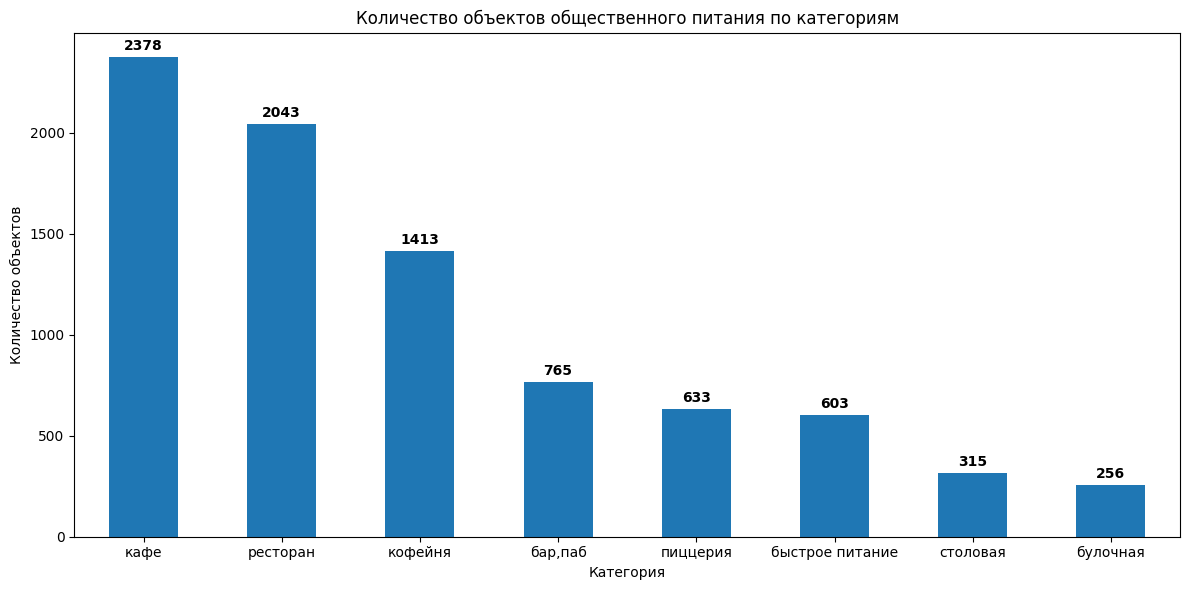

In [74]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))

# Получаем данные для графика
category_counts = df['category'].value_counts()

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
ax = category_counts.plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Количество объектов общественного питания по категориям')

# Настраиваем оформление графика
plt.xlabel('Категория')
plt.ylabel('Количество объектов')


# Добавляем числовые надписи на столбцах
for i, count in enumerate(category_counts):
    plt.text(i, count + 20, str(count),  # x, y позиция и текст
             ha='center', va='bottom',   # выравнивание по центру и снизу
             fontsize=10, fontweight='bold')

# Выводим график
plt.tight_layout()  # Автоматическая подгонка отступов
plt.show()

In [44]:
category_counts = df['category'].value_counts().reset_index()
display(category_counts)

,category,count
0,кафе,2378
1,ресторан,2043
2,кофейня,1413
3,"бар,паб",765
4,пиццерия,633
5,быстрое питание,603
6,столовая,315
7,булочная,256



Три самых популярных заведения Москвы это кафе - 2378 шт, рестораны - 2043 шт, кофейни  - 1413 шт.

Наименее популярны это столовые - 315 шт. и булочные - 256 шт.


### Задача 2
Исследование распределения количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы.

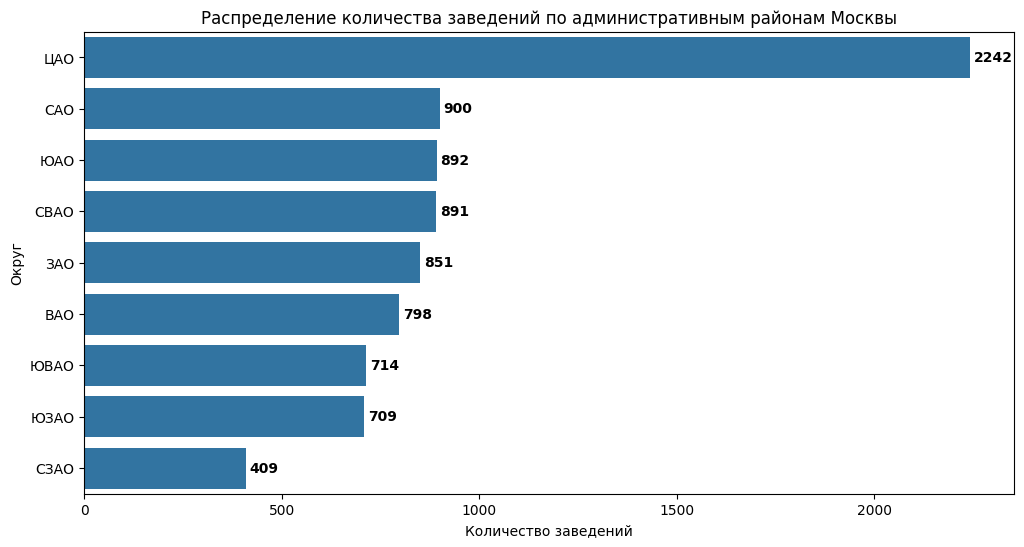

In [75]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))

# Строим линейчатую диаграмму
ax = sns.countplot(data=df,
              y='district',
              order=df['district'].value_counts().index,
              )

# Добавляем подписи к осям и заголовок
plt.ylabel('Округ')
plt.xlabel('Количество заведений')
plt.title('Распределение количества заведений по административным районам Москвы')

# Добавляем числовые подписи на концах столбцов
for i, count in enumerate(df['district'].value_counts().values):
    plt.text(count + 10,  # x-позиция (немного правее конца столбца)
             i,           # y-позиция (соответствует строке)
             str(count),  # текст (количество)
             va='center', # выравнивание по вертикали
             ha='left',   # выравнивание по горизонтали
             fontsize=10,
             fontweight='bold')

# Показываем график
plt.show()





In [46]:
district_counts = df['district'].value_counts().reset_index()
display(district_counts)

,district,count
0,ЦАО,2242
1,САО,900
2,ЮАО,892
3,СВАО,891
4,ЗАО,851
5,ВАО,798
6,ЮВАО,714
7,ЮЗАО,709
8,СЗАО,409



Самое массовое скопление заведений 2242 шт находится в центре Москвы, в остальных районах, за исключением СЗАО = 409 шт, количество заведений находится в интервале от 700 до 900 шт.

 - Распределение заведений каждой категории в Центральном административном округе Москвы

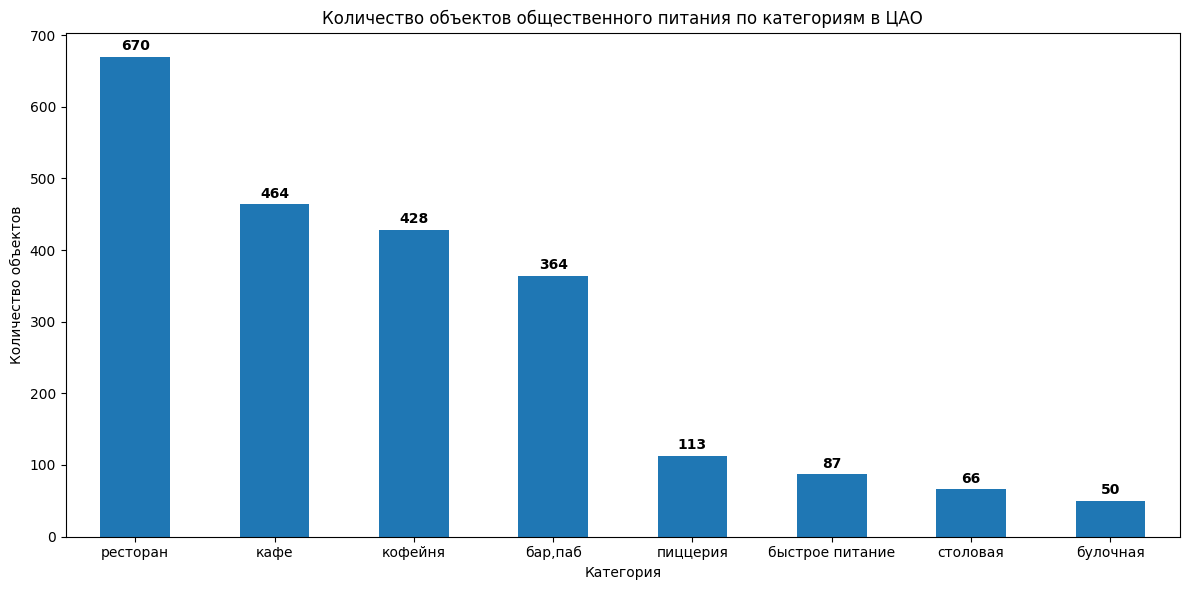

In [76]:
# Выведем ЦАО
cao = df[df['district'] == 'ЦАО']
plt.figure(figsize=(12, 6))

# Строим столбчатую диаграмму
ax = cao['category'].value_counts().plot(
                kind='bar',  # Тип графика - столбчатая диаграмма
                rot=0,  # Градус вращения подписи по оси X
                legend=False,  # Выключаем легенду
                title='Количество объектов общественного питания по категориям в ЦАО')

# Настраиваем оформление графика
plt.xlabel('Категория')
plt.ylabel('Количество объектов')

# Добавляем числовые подписи на столбцах
for i, count in enumerate(cao['category'].value_counts()):
    plt.text(i, count + 5, str(count),  # x, y позиция и текст
             ha='center', va='bottom',   # выравнивание по центру и снизу
             fontsize=10, fontweight='bold')

# Выводим график
plt.tight_layout()
plt.show()

In [48]:
cao = df[df['district'] == 'ЦАО']
cao_counts = cao['category'].value_counts().reset_index()
display(cao_counts)

,category,count
0,ресторан,670
1,кафе,464
2,кофейня,428
3,"бар,паб",364
4,пиццерия,113
5,быстрое питание,87
6,столовая,66
7,булочная,50



Как видно из графика, в ЦАО Москвы преобладают такие заведения как рестораны - 670 шт, кафе - 464 шт, кофейни - 428 шт. и пабы - 364 шт, что в принципе и ожидаемо от центра города.


### Задача 3

Соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения.

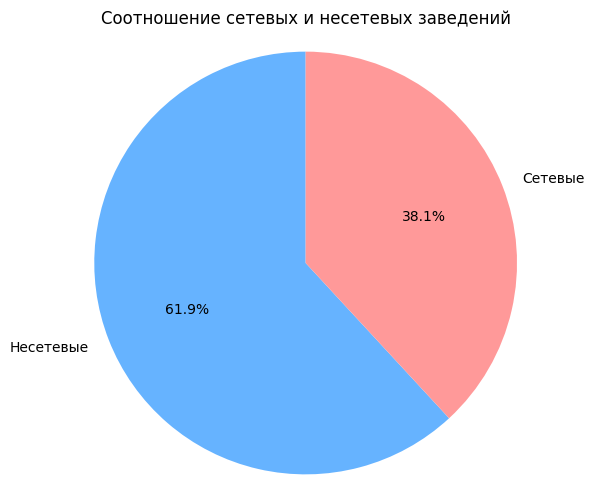

In [49]:
# Простая круговая диаграмма
plt.figure(figsize=(6, 6))

# Данные
labels = ['Несетевые', 'Сетевые']
sizes = df['chain'].value_counts().values
colors = ['#66b3ff', '#ff9999']

# Диаграмма
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Соотношение сетевых и несетевых заведений')
plt.axis('equal')  # Чтобы диаграмма была круглой

plt.show()

Из анализируемых данных видно, что чуть более трети заведений Москвы являются сетевыми.

 - Какие категории заведений чаще являются сетевыми

chain,0,1
category,,
"бар,паб",596,169
булочная,99,157
быстрое питание,371,232
кафе,1599,779
кофейня,693,720
пиццерия,303,330
ресторан,1313,730
столовая,227,88


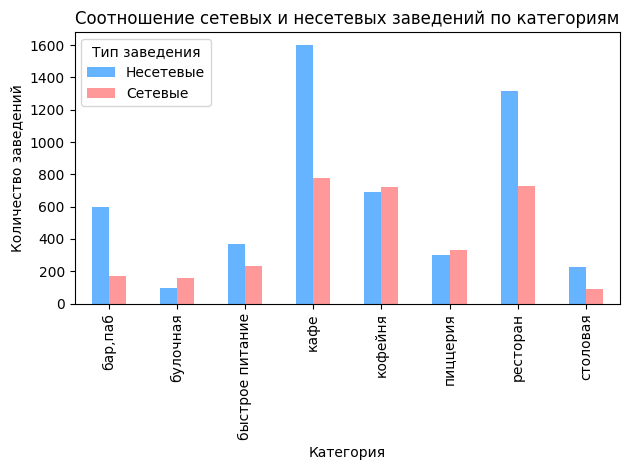

In [77]:
# Создаём таблицу, которая группирует данные по `Chain` и `Category`
df_ch_cat = df.groupby(['category', 'chain']).size().unstack(fill_value=0)
display(df_ch_cat)

# Строим столбчатую диаграмму с теми же цветами, что и в круговой диаграмме
colors = ['#66b3ff', '#ff9999']  # Те же цвета: голубой для несетевых, розовый для сетевых
df_ch_cat.plot(kind='bar', color=colors)

# Настраиваем график
plt.title('Соотношение сетевых и несетевых заведений по категориям') # Заголовок диаграммы
plt.ylabel('Количество заведений') # Подписываем ось Y
plt.xlabel('Категория') # Подписываем ось X
plt.xticks(rotation=90)  # Оставляем метки оси X горизонтальными
plt.legend(title='Тип заведения', labels=['Несетевые', 'Сетевые'])  # Легенда для разбивки

# Отображаем график
plt.tight_layout()
plt.show()



В основном сетевыми заведениями в Москве являются булочные, их в 1,58 раз больше, чем несетевых. И практически равное количество сетевых и несетевых пиццерий и кофеен.


### Задача 4

Количество посадочных мест в заведениях.

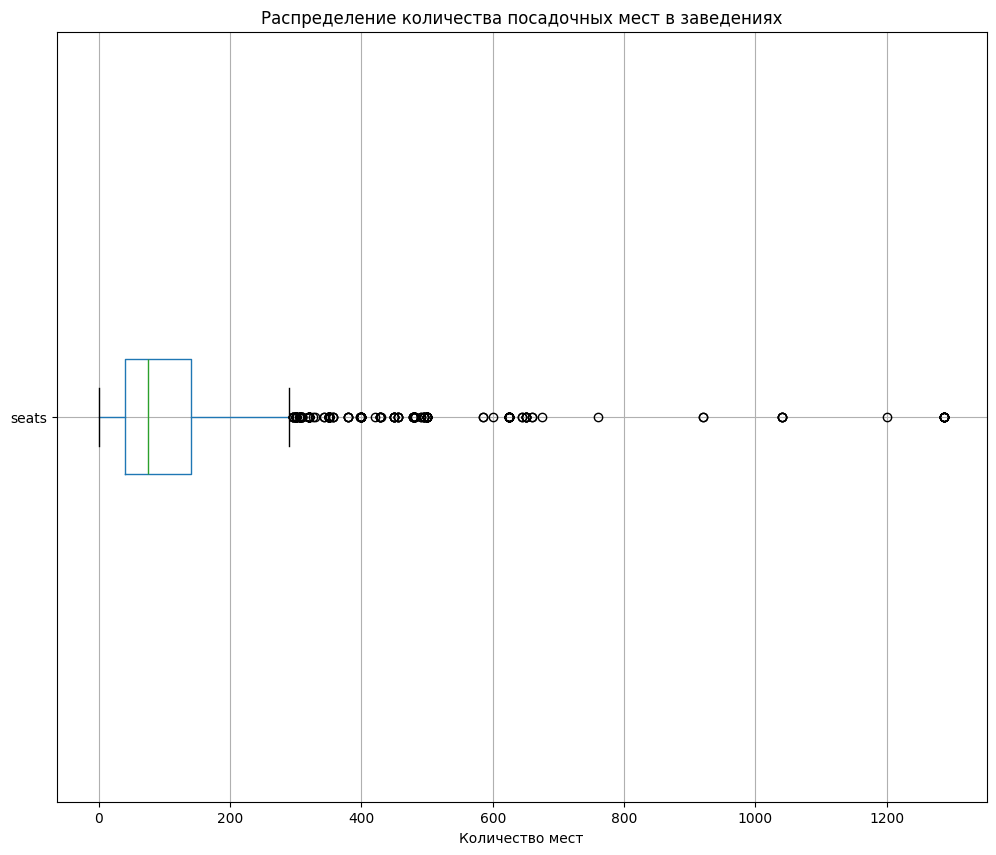

In [51]:
boxplot = df.boxplot(column='seats',
                     vert=False,
                     figsize=(12, 10))

# Добавляем заголовок и метку оси X
boxplot.set_title('Распределение количества посадочных мест в заведениях')
boxplot.set_xlabel('Количество мест')

plt.show()

В поцессе анализа, как и предполагалост ранее, видны аномальные выбросы по количеству посадочных мест, что может исказить дальнейший анализ. Из ящика с усами можно увидеть, что диаграммы размаха имеет неравномерное распределение, скошена вправо. Медиана находится на норамльном значении, на уровне 100 посадочных мест, межквартильных размах небольшой. Из графика также видно, что первый квартиль находится на значении 0, мне кажется, что в данных много заведений без посадочных мест, типа булочных, пицеррий, работающих на вынос. На счет выбросов, я бы их оставила.

- Количество посадочных мест по категориям.

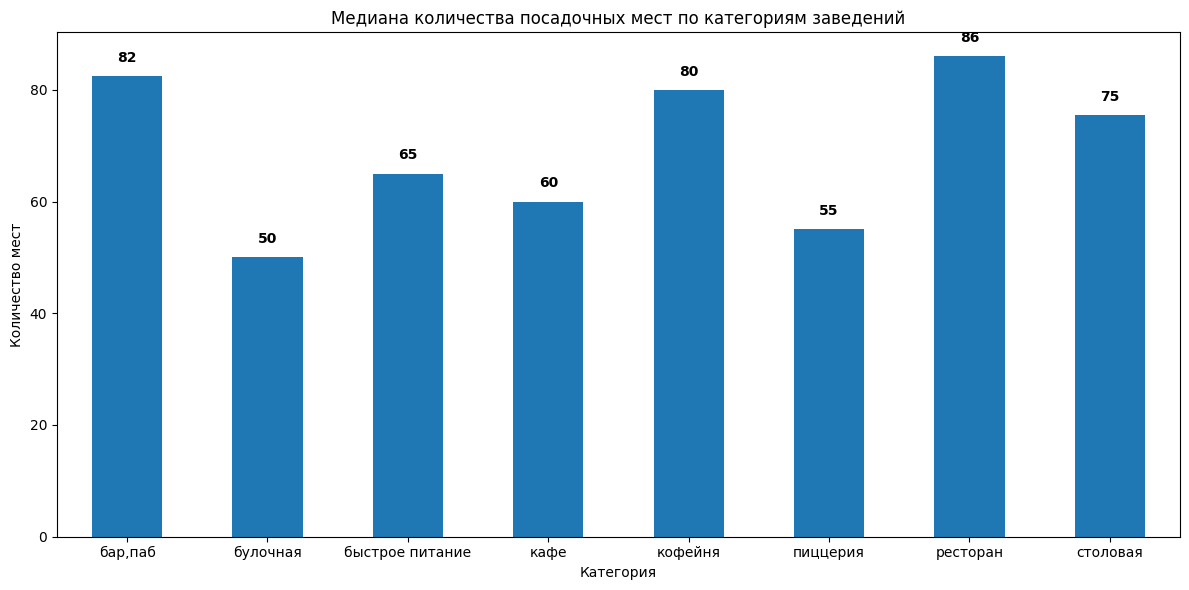

In [78]:
plt.figure(figsize=(12, 6))

# построим график медианного количества мест по категориям
ax = df.groupby('category')['seats'].median().plot(
    kind='bar',  # Тип графика - столбчатая диаграмма
    rot=0,  # Градус вращения подписи по оси X
    legend=False,  # Выключаем легенду
    title='Медиана количества посадочных мест по категориям заведений'
)

plt.xlabel('Категория')
plt.ylabel('Количество мест')

# Добавляем числовые подписи на столбцах
for i, value in enumerate(df.groupby('category')['seats'].median()):
    plt.text(i, value + 2, f'{int(value)}',  # x, y позиция и текст (целое число)
             ha='center', va='bottom',       # выравнивание по центру и снизу
             fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()



In [54]:
seats_count = df.groupby('category')['seats'].median()
seats_count = seats_count.sort_values(ascending=False).round(0).astype(int)
seats_count = seats_count.reset_index()

display(seats_count)

,category,seats
0,ресторан,86
1,"бар,паб",82
2,кофейня,80
3,столовая,76
4,быстрое питание,65
5,кафе,60
6,пиццерия,55
7,булочная,50



Наибольшее количество посадочных мест в ресторанах - 86 мест, пабах - 82 места, кофейнях - 80 мест. Наименьшее количество посадочных мест в булочных и пиццериях, они в основном работают на вынос.


### Задача 5

Исследование рейтинга заведений.

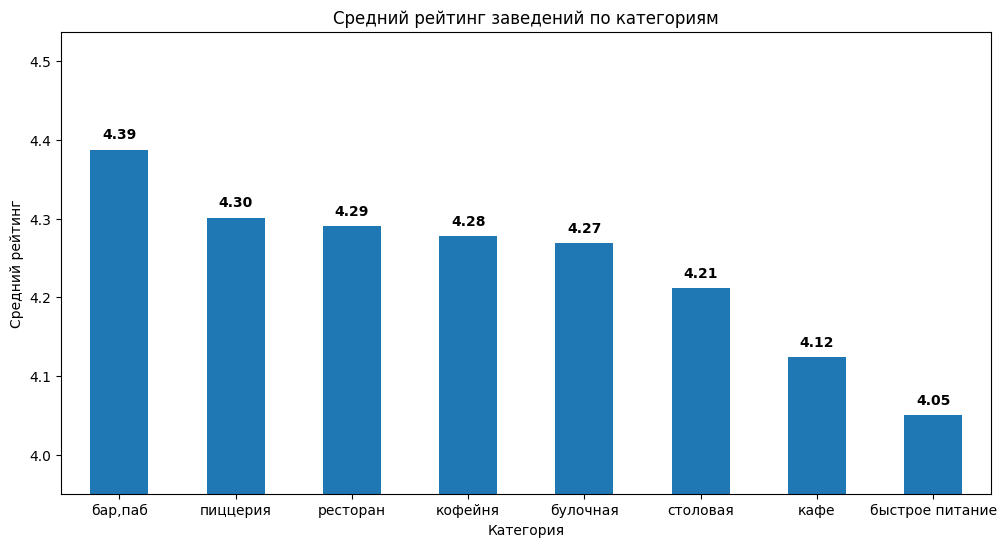

In [79]:
plt.figure(figsize=(12, 6))

# Получаем данные для графика
rating_by_category = df.groupby('category')['rating'].mean().sort_values(ascending=False)

# Строим график
bars = rating_by_category.plot(
    kind='bar',
    rot=0,
    legend=False,
    title='Средний рейтинг заведений по категориям'
)

# Добавляем подписи значений на столбцах
for i, (category, rating) in enumerate(rating_by_category.items()):
    plt.text(i, rating + 0.01, f'{rating:.2f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel('Категория')
plt.ylabel('Средний рейтинг')
plt.ylim(rating_by_category.min() - 0.1, rating_by_category.max() + 0.15)  # Расширяем оси для подписей

plt.show()





Из графика видно, что средний рейтинг заведений по категориям практически не отличается и равен около 4 баллов. Заказчику придется выделяться, чтобы удерживать рейтинг на уровне.


### Задача 6

Матрица корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным.

In [56]:
# Вычисляем корреляционную матрицу с использованием phi_k
cor_matrix = df[['category', 'district', 'chain', 'seats', 'price','is_24_7', 'rating']].phik_matrix()
cor_matrix.loc[cor_matrix.index !='rating'][['rating']].sort_values(by = 'rating', ascending = False)



interval columns not set, guessing: ['chain', 'seats', 'rating']


,rating
price,0.281294
district,0.200691
category,0.190003
is_24_7,0.150173
chain,0.108092
seats,0.000000


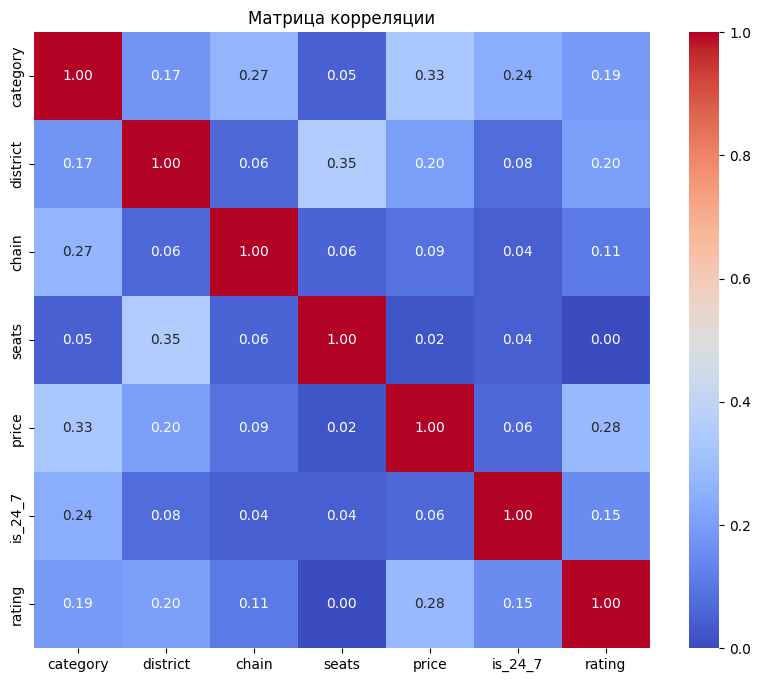

In [57]:
plt.figure(figsize=(10, 8))
sns.heatmap(cor_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Матрица корреляции')
plt.show()


Наибольшая корреляционная связь наблюдается между рейтингом и прайсом. Но как видно из матрицы корреляции эта связь слабая, далека от единицы.

<Axes: title={'center': 'Связь между рейтингом и прайсом'}, xlabel='rating', ylabel='price'>

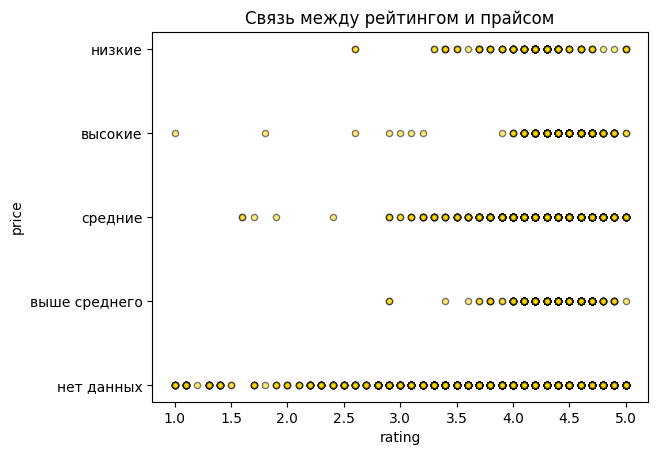

In [58]:
df.plot(kind='scatter',
          x='rating',
          y='price',
          alpha=0.5,
          color='gold',
          edgecolor='k',
          title='Связь между рейтингом и прайсом')


Диаграмма рассеивания подтвержает слабую связь между рейтингом и прайсом.


### Задача 7

Топ-15 популярных сетей в Москве.

In [59]:
# Оставим только сетевые заведения Москвы
only_chain_df = df[df['chain'] == 1]
# Сгруппируем по названию
chain_name_df = only_chain_df.groupby('name').agg(count=('name', 'size'),
                                                  average_rating=('rating', 'mean'),
                                                  category=('category', 'first')).reset_index()
# Вывод топ 15 заведений Москвы (только сетевые)
top_15 = chain_name_df.sort_values(('count'), ascending=False).head(15)
display(top_15[['name', 'category', 'average_rating']])








,name,category,average_rating
729,шоколадница,кофейня,4.177500
335,домино'с_пицца,пиццерия,4.169737
331,додо_пицца,пиццерия,4.286486
147,one_price_coffee,кофейня,4.064789
743,яндекс_лавка,ресторан,3.872464
58,cofix,кофейня,4.075385
168,prime,ресторан,4.116000
664,хинкальная,быстрое питание,4.322727
409,кофепорт,кофейня,4.147619
418,кулинарная_лавка_братьев_караваевых,кафе,4.394872


/tmp/ipython-input-2541505121.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='count',


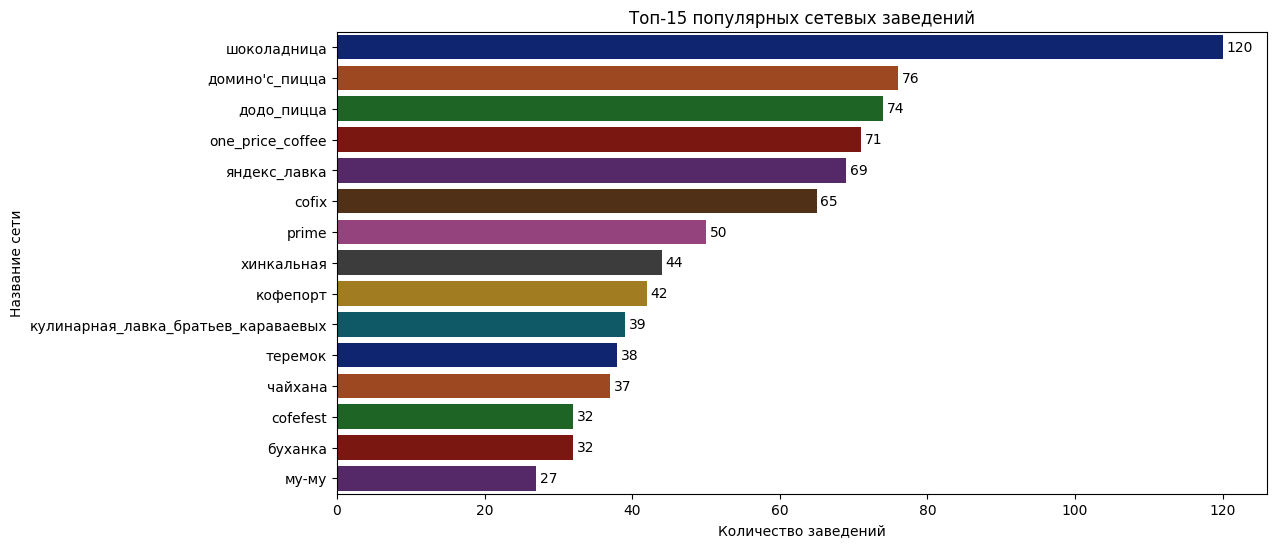

In [60]:
plt.figure(figsize=(12, 6))
# Построим график топ 15 заведений
ax = sns.barplot(x='count',
            y='name',
            data=top_15,
            palette='dark')

plt.title('Топ-15 популярных сетевых заведений')
plt.xlabel('Количество заведений')
plt.ylabel('Название сети')

# Добавляем подписи количества на концах столбцов
for i, (index, row) in enumerate(top_15.iterrows()):
    plt.text(row['count'] + 0.5,  # x-позиция (немного правее конца столбца)
             i,                    # y-позиция (соответствует строке)
             f"{int(row['count'])}",  # текст (целое число)
             va='center',         # выравнивание по вертикали
             ha='left',           # выравнивание по горизонтали
             fontsize=10)

plt.show()

 - Вывод среднего рейтинга заведений

/tmp/ipython-input-285560304.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='average_rating',


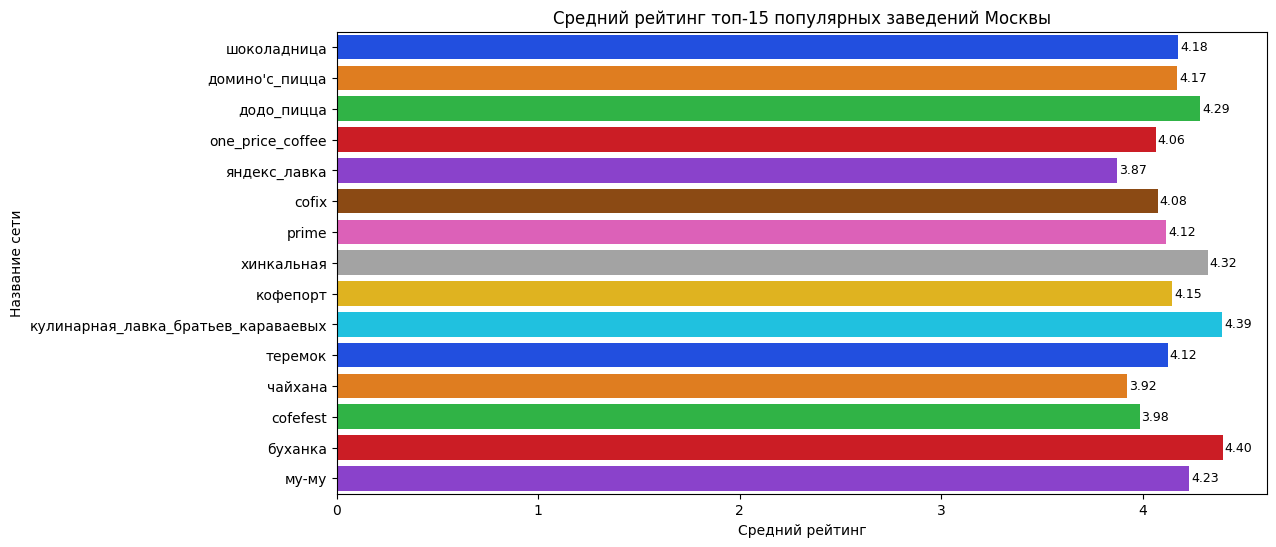

In [61]:
plt.figure(figsize=(12, 6))

# Визуализация среднего рейтинга
ax = sns.barplot(x='average_rating',
                 y='name',
                 data=top_15,
                 palette='bright')

plt.title('Средний рейтинг топ-15 популярных заведений Москвы')
plt.xlabel('Средний рейтинг')
plt.ylabel('Название сети')

# Добавляем числовые подписи на концах столбцов
for i, (index, row) in enumerate(top_15.iterrows()):
    # Добавляем текст со значением рейтинга
    plt.text(row['average_rating'] + 0.01,  # x-позиция (правее конца столбца)
             i,                              # y-позиция (соответствует строке)
             f"{row['average_rating']:.2f}", # текст (округление до 2 знаков)
             va='center',                    # выравнивание по вертикали
             ha='left',                      # выравнивание по горизонтали
             fontsize=9)

plt.show()


Топ 3 сетевых заведений Москвы:
    
 - буханка, относится к категории булочная, средний рейтинг	4.40
    
 - кулинарная лавка Караваевых, относится к категории кафе, средний рейтинг	4.39
    
 - хинкальная, относится к категории быстрое питание, средний рейтинг	4.32
    
    


### Задача 8

Анализ цен в Центральном административном округе и других.


,district,middle_avg_bill
0,ВАО,642.560150
1,ЗАО,866.947121
2,САО,722.239444
3,СВАО,586.111111
4,СЗАО,737.911980
5,ЦАО,1013.758252
6,ЮАО,705.628924
7,ЮВАО,534.656863
8,ЮЗАО,642.901269


/tmp/ipython-input-1577276977.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='district',


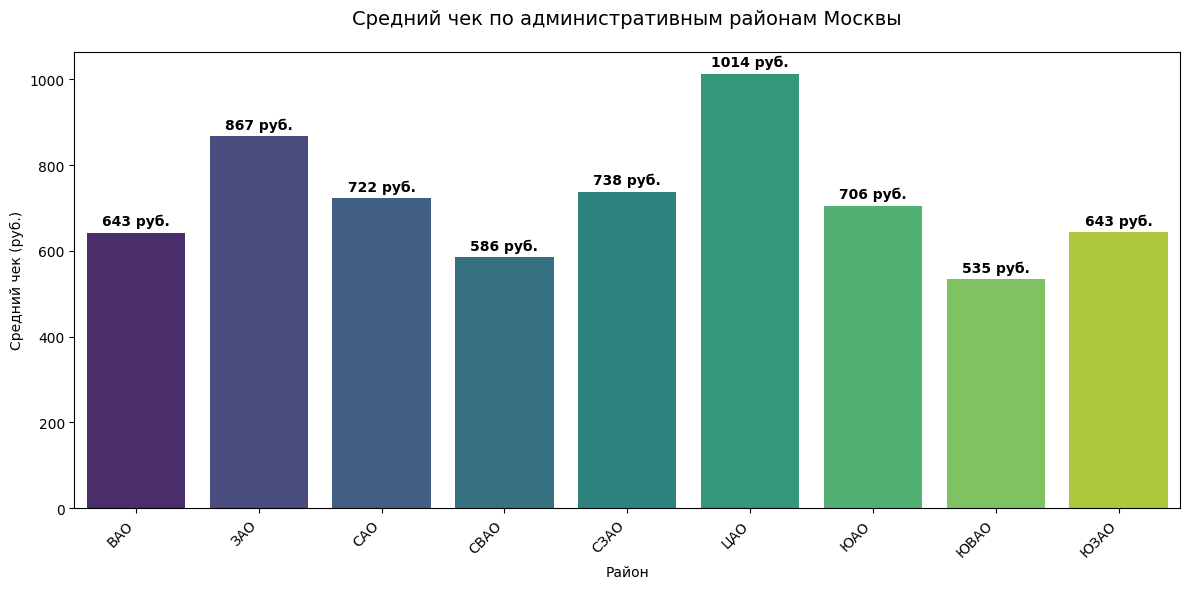

In [62]:
district_bill = df.groupby('district')['middle_avg_bill'].mean().reset_index()
display(district_bill)

plt.figure(figsize=(12, 6))
# построим график среднего чека по районам
ax = sns.barplot(x='district',
                 y='middle_avg_bill',
                 data=district_bill,
                 palette='viridis')

plt.xlabel('Район')
plt.ylabel('Средний чек (руб.)')
plt.title('Средний чек по административным районам Москвы', fontsize=14, pad=20)

# Добавляем подписи значений на столбцах
for i, (index, row) in enumerate(district_bill.iterrows()):
    plt.text(i,  # x-позиция (индекс столбца)
             row['middle_avg_bill'] + 10,  # y-позиция (немного выше столбца)
             f"{row['middle_avg_bill']:.0f} руб.",  # текст (округление до целого)
             ha='center',  # выравнивание по центру
             va='bottom',  # выравнивание по низу
             fontsize=10,
             fontweight='bold')

plt.xticks(rotation=45, ha='right')  # Наклон подписей оси X для лучшей читаемости
plt.tight_layout()  # Автоматическая подгонка отступов
plt.show()


Топ 3 среднего счета по районам:
    
- ЦАО - 1014 руб
    
- ЗАО - 867 руб
    
- СЗАО - 738 руб

Не зря в ЦАО больше ресторанов


### Задача 9

Часы работы заведений или стоимость чашки кофе в зависимости от расположения или типа заведения.


In [63]:
# Определяем процент заведений, для которых известна стоимость кофе
non_null_count = df['middle_coffee_cup'].notna().sum()
total_count = len(df)
coverage_percent = (non_null_count / total_count * 100).round(2)
display (coverage_percent)


np.float64(6.36)

Так как данных по стоимости чашки каппучино составляет всего около 7%, то делать выводы из такого количества данных нет необходимости.


### Промежуточный вывод



 - Популярность заведений: Наиболее популярными являются кафе (2378), рестораны (2043) и кофейни (1413), в то время как столовые (315) и булочные (256) менее популярны.

 - Распределение по районам: Наибольшее количество заведений сосредоточено в центре Москвы (2242), в то время как в других районах количество заведений варьируется от 700 до 900.

 - Сетевые заведения: Булочные являются наиболее распространенными сетевыми заведениями, их количество превышает несетевые в 1,58 раз.

 - Посадочные места: Рестораны имеют наибольшее количество посадочных мест (86), в то время как булочные и пиццерии имеют наименьшее количество мест, так как работают в основном на вынос.

 - Рейтинг и цена: Средний рейтинг заведений по категориям составляет около 4 баллов, а корреляция между рейтингом и ценой слабая.

 - Топ сетевых заведений: буханка, средний рейтинг	4.40, кулинарная лавка Караваевых, средний рейтинг	4.39, хинкальная, средний рейтинг	4.32.

 - Средний счет по районам: Средний счет в ЦАО составляет 1014 руб., в ЗАО - 867 руб., а в СЗАО - 738 руб.

##  Итоговый вывод и рекомендации

На основе проведенного анализа данных о заведениях в Москве можно выделить несколько ключевых выводов и предложений для дальнейших действий:

 - Популярность заведений: Наиболее востребованными являются кафе (2378), рестораны (2043) и кофейни (1413). Рекомендуется остановиться на этих категориях, так как они привлекают наибольшее количество клиентов.

 - Распределение по районам: Центр Москвы (2242 заведения) является наиболее насыщенной зоной. Как вариант можно рассмотреть возможность открытия новых заведений в менее насыщенных районах, где количество заведений варьируется от 700 до 900, чтобы привлечь клиентов, которые ищут разнообразие.

- Сетевые заведения: Булочные являются наиболее распространенными сетевыми заведениями, их количество превышает несетевые в 1,58 раз. Это может свидетельствовать о высоком спросе на подобные форматы.

- Посадочные места: Рестораны имеют наибольшее количество посадочных мест (86), что делает их более привлекательными для  посещений. Рекомендуется рассмотреть возможность увеличения вместимости в других категориях, таких как кофейни и пиццерии, чтобы удовлетворить потребности клиентов.

- Рейтинг и цена: Средний рейтинг заведений составляет около 4 баллов, а корреляция между рейтингом и ценой слабая. Это указывает на то, что клиенты могут не всегда связывать высокую цену с высоким качеством.

- Топ сетевых заведений: буханка, относится к категории булочная, кулинарная лавка Караваевых, относится к категории кафе, хинкальная, относится к категории быстрое питание, являются лидерами по популярности среди сетевых заведений. Рекомендуется изучить их стратегии и подходы к обслуживанию клиентов для возможного внедрения успешных практик.

- Средний счет по районам: Средний счет в ЦАО составляет 1014 руб., в ЗАО - 867 руб., а в СЗАО - 738 руб. Это может помочь в формировании ценовой политики для новых заведений, учитывая платежеспособность клиентов в разных районах.


